In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mart_ticket_modeling.csv")

print(df.shape)
df.head()

(10000, 52)


,ticket_id,booking_id,issue_category,contact_channel,priority_initial,guest_id,host_id,listing_id,nights,days_until_checkin_at_ticket,...,senior_agent_routing,rebooking_coupon_offered,repeat_contact_probability,repeat_contact_7d,escalation_probability,escalated,resolution_hours,csat_score,poor_csat,long_resolution
0,T000000,B000000,payment_problem,email,high,G00882,H00938,L02865,9,12,...,1,0,0.088,0,0.089,0,4.98,5,0,0
1,T000001,B000001,policy_question,chat,medium,G01659,H00095,L00570,2,2,...,1,0,0.223,0,0.114,0,4.80,5,0,0
2,T000002,B000002,refund_request,chat,medium,G03280,H00088,L01038,8,4,...,1,0,0.265,0,0.122,0,13.65,5,0,0
3,T000003,B000003,refund_request,phone,low,G03348,H01238,L00180,5,7,...,0,1,0.492,1,0.328,0,22.14,4,0,0
4,T000004,B000004,policy_question,chat,low,G03456,H00039,L00952,5,28,...,0,0,0.338,0,0.139,0,2.02,4,0,0


In [2]:
treatment = "senior_agent_routing"
outcome = "repeat_contact_7d"

print("Treatment rate:", df[treatment].mean())
print("Outcome rate:", df[outcome].mean())

Treatment rate: 0.3224
Outcome rate: 0.3715


In [6]:
naive = (
    df.groupby(treatment)
    .agg(
        tickets=(outcome, "count"),
        repeat_contact_rate=(outcome, "mean"),
        avg_urgency=("urgency_score", "mean"),
        avg_sentiment=("sentiment_score", "mean"),
        safety_issue_rate=("issue_category", lambda x: (x == "safety_issue").mean()),
        host_cancellation_rate=("issue_category", lambda x: (x == "host_cancellation").mean()),
        same_week_rate=("same_week_checkin_flag", "mean")
    )
)

naive

,tickets,repeat_contact_rate,avg_urgency,avg_sentiment,safety_issue_rate,host_cancellation_rate,same_week_rate
senior_agent_routing,,,,,,,
0,6776,0.371606,0.431181,-0.213944,0.025531,0.105224,0.194510
1,3224,0.371278,0.537402,-0.308791,0.128722,0.225186,0.263648


In [7]:
naive_effect = (
    naive.loc[1, "repeat_contact_rate"]
    - naive.loc[0, "repeat_contact_rate"]
)

print(f"Naive difference: {naive_effect:.2%}")

Naive difference: -0.03%


In [8]:
confounders = [
    "issue_category",
    "contact_channel",
    "priority_initial",
    "days_until_checkin_at_ticket",
    "same_week_checkin_flag",
    "strict_policy_flag",
    "host_cancelled_booking_flag",
    "high_value_booking_flag",
    "total_booking_value",
    "nights",
    "sentiment_score",
    "urgency_score",
    "time_to_first_agent_response_minutes",
    "message_count_first_30min",
    "guest_account_age_days",
    "guest_past_bookings_count",
    "guest_past_support_tickets_12m",
    "guest_past_refund_requests_12m",
    "guest_lifetime_booking_value",
    "guest_id_verified",
    "host_superhost",
    "host_response_rate",
    "host_cancellation_rate_12m",
    "host_avg_response_time_minutes",
    "host_past_guest_complaints_12m",
    "host_avg_rating",
    "listing_review_score",
    "listing_cleanliness_score",
    "listing_accuracy_score",
    "listing_review_count",
    "cancellation_policy",
    "instant_book_enabled"
]

confounders = [c for c in confounders if c in df.columns]

X = df[confounders].copy()
T = df[treatment].astype(int)
Y = df[outcome].astype(int)

print(X.shape)

(10000, 32)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

cat_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

propensity_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

propensity_model.fit(X, T)

df["propensity_score"] = propensity_model.predict_proba(X)[:, 1]

print("Propensity AUC:", roc_auc_score(T, df["propensity_score"]))
df["propensity_score"].describe()

/var/folders/78/y2_1gdzn2kd4k_m309p88yxw0000gn/T/ipykernel_11278/1462785912.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()


Propensity AUC: 0.6809845213437589


/Users/adityasharma/Desktop/airbnb/.venv-1/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


count    10000.000000
mean         0.479679
std          0.159681
min          0.174164
25%          0.353877
50%          0.428918
75%          0.612825
max          0.933807
Name: propensity_score, dtype: float64

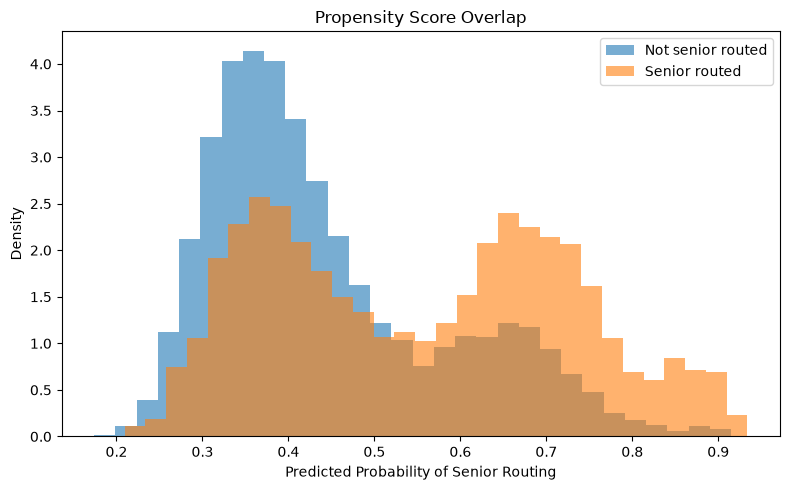

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df[treatment] == 0, "propensity_score"],
    bins=30,
    alpha=0.6,
    label="Not senior routed",
    density=True
)

plt.hist(
    df.loc[df[treatment] == 1, "propensity_score"],
    bins=30,
    alpha=0.6,
    label="Senior routed",
    density=True
)

plt.title("Propensity Score Overlap")
plt.xlabel("Predicted Probability of Senior Routing")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()